The goal of this project is to model the shock of one corner of a 2025 Nissan Versa S CVT aftr hitting a speed bump. Using the official Nissan brochure, the weight of the vehicle is 2652 lbs or 1203 kg (301kg per corner). The suspension is an independent strut front suspension with a torsion beam rear suspension so for simplicity sake, a single corner will be used with an effective sprung mass of 250 kg. For the speedbump, a bump with 3.5 inches in height and 12 feet of length will be used. The initial y will be .05m and the initial y' will be 0 as the car is just crossing the hump. The model used will be my'' + cy' + ky = 0. The coefficients are m = 250 kg, k = 16000 N/m, and c = 1000 Ns/m. 

To convert this to a system of first order ODEs, y1 and y2 are defined as y1 = y, y2 = y'. This yields the system y1' = y2, y2' = -(c/m)y2 - (k/m)y1. 

The spring constant k represents the amount of force applied to a spring (N) which causes a respective amount of displacement of the spring (m). The damping constant c represents the strength of the force that resists the motion of the spring. Its proportional to the velocity of the spring and causes the oscilation to reduce in amplitude over time. m is just the effective sprung mass of one quarter of the car, y(0) is the initial displacement (the height of the speed bump), and v(0) is the starting vertical velocity (0).

| Parameter | Value | Source |
|:--------:|:--------:|:--------:|
|  Effective sprung mass m   |  250 kg   |  Source 1 |
|  Spring constant k   |  16000 N/m   |  Source 2   |
|  Damping coefficient c   |  1000 Ns/m   |  Source 2   |
|  Initial displacement y(0)   |  0.05 m   |  Source 3   |
|  Initial velocity y'(0)   |  0 m/s   |  Source 3   |

The reason an effective sprung mass of 250 kg is used is because the suspension on the vehicle uses both an independent strut front suspension and torsion beam rear suspension which allows the actual suspension to effectively be damping slightly less of a fourth of the cars weight at each wheel on average as the suspension geometry is not a very simple vertical beam. This leads to an estimation of 250 kg being used. The damping coefficient and spring constant are both taken from a simplified quarter car suspension study done. The initial displacement and velocity are based on a Federal Highway Administration reporting stating public road speed bumps as being roughly 0.05 meters high. The physical scenario being modeled is a spring starting at 0 velocity and a displacement of 0.05 m damping the oscilations of a 250 kg mass. The spring has damping coeffieint and spring constant of 1000 Ns/m and 16000 N/m respectively. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 250.0
c = 1000.0
k = 16000.0

h_values = [0.01, 0.025, 0.05, 0.10, 0.25, 0.50]

t_start = 0
t_end = 5
y_0 = 0.05
v_0 = 0.0



In [2]:
def analytical_solution(t):
    w_n = np.sqrt(k / m)
    z = c / (2.0 * np.sqrt(k * m))
    w_d = w_n * np.sqrt(1.0 - z**2)

    A = y_0
    B = (v_0 + z * w_n * y_0) / w_d

    y = np.exp(-z * w_n * t) * (A * np.cos(w_d * t) + B * np.sin(w_d * t))
    v = np.exp(-z * w_n * t) * (-z * w_n * (A * np.cos(w_d * t) + B * np.sin(w_d * t)) + (-A * w_d * np.sin(w_d * t) + B * w_d * np.cos(w_d * t)))
    return y, v

# Function to apply Euler's method for a given step size
def euler_method(h, m, c, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        # Update equations for Euler
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-(c / m) * v_n - (k / m) * y_n)

    return t_values, y_values, v_values

# Function to apply RK4 for given step size
def rk4_method(h, m, c, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        # Four stage update equations for RK4
        k1_y = v_n
        k1_v = -(c / m) * v_n - (k / m) * y_n

        k2_y = v_n + (h / 2.0) * k1_v
        k2_v = -(c / m) * (v_n + (h / 2.0) * k1_v) - (k / m) * (y_n + (h / 2.0) * k1_y)

        k3_y = v_n + (h / 2.0) * k2_v
        k3_v = -(c / m) * (v_n + (h / 2.0) * k2_v) - (k / m) * (y_n + (h / 2.0) * k2_y)

        k4_y = v_n + h * k3_v
        k4_v = -(c / m) * (v_n + h * k3_v) - (k / m) * (y_n + h * k3_y)

        y_values[i] = y_n + (h / 6.0) * (k1_y + 2.0 * k2_y + 2.0 * k3_y + k4_y)
        v_values[i] = v_n + (h / 6.0) * (k1_v + 2.0 * k2_v + 2.0 * k3_v + k4_v)

    return t_values, y_values, v_values

# Function for determining stability of RK4 for given z value
def rk4_stability(z):
    return 1.0 + z + (z**2) / 2.0 + (z**3) / 6.0 + (z**4) / 24.0

In [3]:
# Eigenvalues and max stable step size
A = np.array([[0.0, 1.0], [-(k / m), -(c / m)]])
eigenvalues = np.linalg.eigvals(A)

h_max_euler = c / k

lambdasys = eigenvalues[0]
h_test = np.linspace(0.0, 1.0, 200001)
rk4_values = np.abs(rk4_stability(h_test * lambdasys)) - 1.0

first_bad = np.where(rk4_values > 0.0)[0][0]
left = h_test[first_bad - 1]
right = h_test[first_bad]

for i in range(60):
    mid = 0.5 * (left + right)
    if np.abs(rk4_stability(mid * lambdasys)) <= 1.0:
        left = mid
    else:
        right = mid

h_max_rk4 = 0.5 * (left + right)

print("h_max_euler =", h_max_euler)
print("h_max_rk4 =", h_max_rk4)

h_max_euler = 0.0625
h_max_rk4 = 0.3620871713882382


In [4]:
# Get results for all euler cases
euler_results = []

for h in h_values:
    t_values, y_values, v_values = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    y_exact, v_exact = analytical_solution(t_values)
    euler_results.append((h, t_values, y_values, v_values))
    
# Get results for all RK4 cases
rk4_results = []

for h in h_values:
    t_values, y_values, v_values = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    y_exact, v_exact = analytical_solution(t_values)
    rk4_results.append((h, t_values, y_values, v_values))

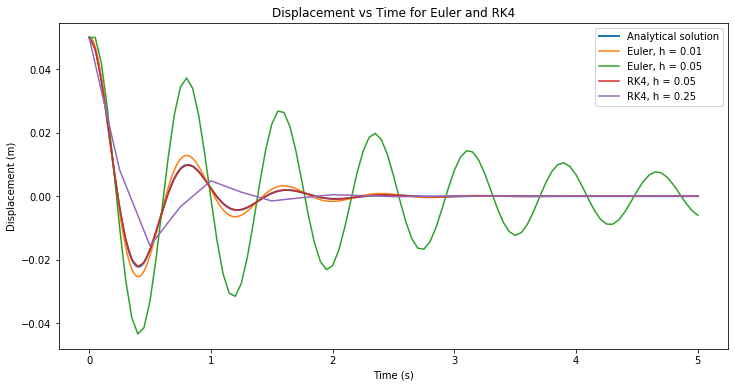

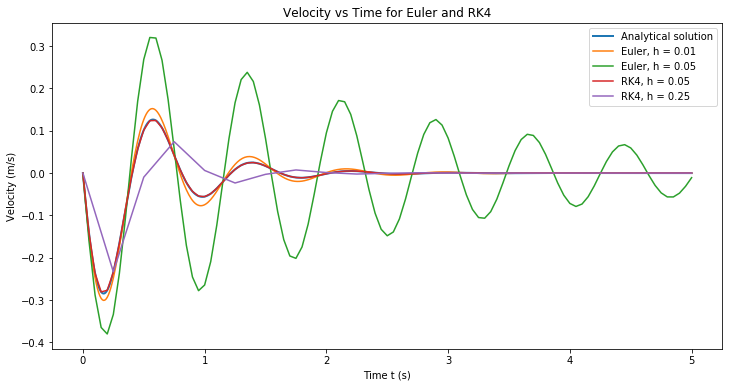

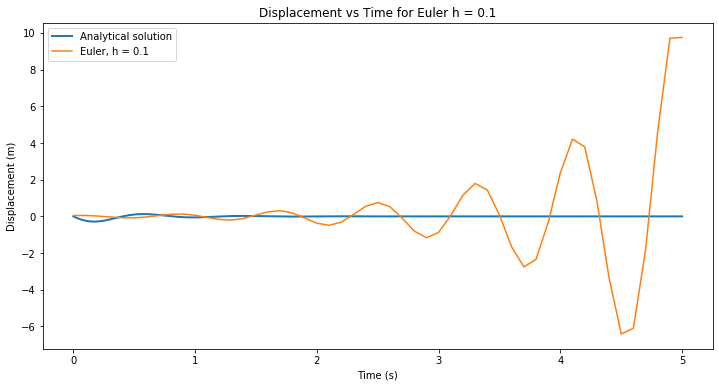

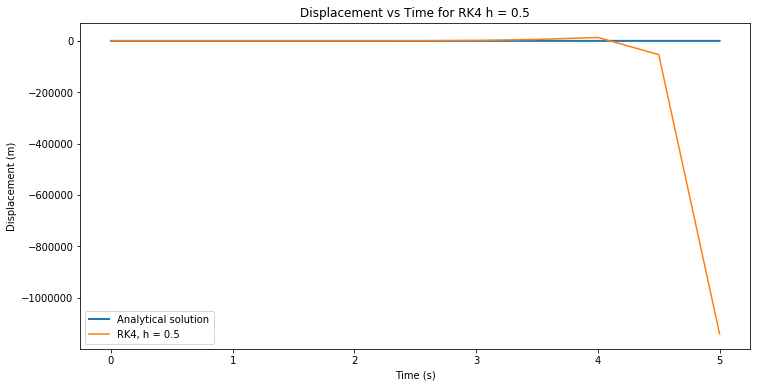

In [5]:
# Analytical solution
t_exact_plot = np.linspace(t_start, t_end, 5000)
y_exact_plot, v_exact_plot = analytical_solution(t_exact_plot)

# Displacement vs time
plt.figure(figsize=(12, 6))
plt.plot(t_exact_plot, y_exact_plot, label="Analytical solution", linewidth=2)

for h, t_values, y_values, v_values in euler_results:
    if h == 0.01 or h == 0.05:
        plt.plot(t_values, y_values, label="Euler, h = {}".format(h))

for h, t_values, y_values, v_values in rk4_results:
    if h == 0.05 or h == 0.25:
        plt.plot(t_values, y_values, label="RK4, h = {}".format(h))

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Displacement vs Time for Euler and RK4")
plt.legend()

# Velocity vs time
plt.figure(figsize=(12, 6))
plt.plot(t_exact_plot, v_exact_plot, label="Analytical solution", linewidth=2)

for h, t_values, y_values, v_values in euler_results:
    if h == 0.01 or h == 0.05:
        plt.plot(t_values, v_values, label="Euler, h = {}".format(h))

for h, t_values, y_values, v_values in rk4_results:
    if h == 0.05 or h == 0.25:
        plt.plot(t_values, v_values, label="RK4, h = {}".format(h))

plt.xlabel("Time t (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity vs Time for Euler and RK4")
plt.legend()

# Position vs time for unstable euler and rk4 h values

plt.figure(figsize=(12, 6))
plt.plot(t_exact_plot, v_exact_plot, label="Analytical solution", linewidth=2)

for h, t_values, y_values, v_values in euler_results:
    if h == 0.1:
        plt.plot(t_values, y_values, label="Euler, h = {}".format(h))
        
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Displacement vs Time for Euler h = 0.1")
plt.legend()

plt.figure(figsize=(12, 6))
plt.plot(t_exact_plot, v_exact_plot, label="Analytical solution", linewidth=2)

for h, t_values, y_values, v_values in rk4_results:
    if h == 0.5:
        plt.plot(t_values, y_values, label="RK4, h = {}".format(h))

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Displacement vs Time for RK4 h = 0.5")
plt.legend()

The code displays four plots here. The first two show the displacement vs time as well as the velocity vs time plots for the analytical solution, euler solution at differing h values, and the RK4 solution at differing h values. Visually on these plots we can see that both the RK4 and euler method increase in accuracy and converge towards the analytical solution as the step size decreases which is the expected outcome. RK4 is quicker than the Euler method at approaching the analytical solution as the step size decreases which is evident as at a step size of 0.05 RK4 has nearly converged with the analytical solution while the euler method is still far from accurate. We can see as well that RK4 is even reasonably accurate at a step size of 0.25 while at this step size Euler is still unstable. 

The velocity vs time graph parrots the same findings that are seen when comparing the accuracy of the two methods on the position vs time graph. This is expected as the accuracy or RK4 is expected to be superior to euler at the same step size and the velocity analytical solution is mathematically nearly identical to the position analytical solution. Both are an exponential compenent multiplied by a sinusoidal component. 

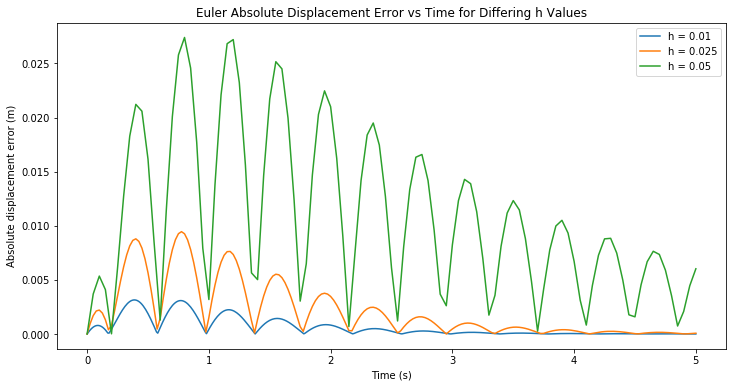

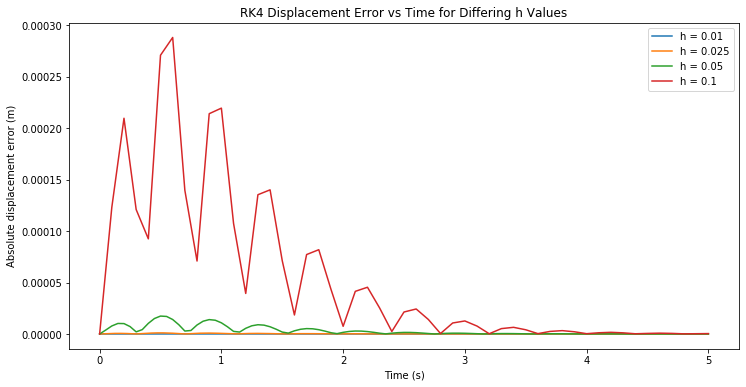

In [6]:
# Euler error vs time
plt.figure(figsize=(12, 6))

for h, t_values, y_values, v_values in euler_results:
    if h == 0.01 or h == 0.025 or h == 0.05:
        y_exact, v_exact = analytical_solution(t_values)
        plt.plot(t_values, np.abs(y_values - y_exact), label="h = {}".format(h))

plt.xlabel("Time (s)")
plt.ylabel("Absolute displacement error (m)")
plt.title("Euler Absolute Displacement Error vs Time for Differing h Values")
plt.legend()

# RK4 error vs time
plt.figure(figsize=(12, 6))

for h, t_values, y_values, v_values in rk4_results:
    if h == 0.01 or h == 0.025 or h == 0.05 or h == 0.10:
        y_exact, v_exact = analytical_solution(t_values)
        plt.plot(t_values, np.abs(y_values - y_exact), label="h = {}".format(h))

plt.xlabel("Time (s)")
plt.ylabel("Absolute displacement error (m)")
plt.title("RK4 Displacement Error vs Time for Differing h Values")
plt.legend()

euler_slope = 1.1069888242387302
rk4_slope = 4.017505975801624


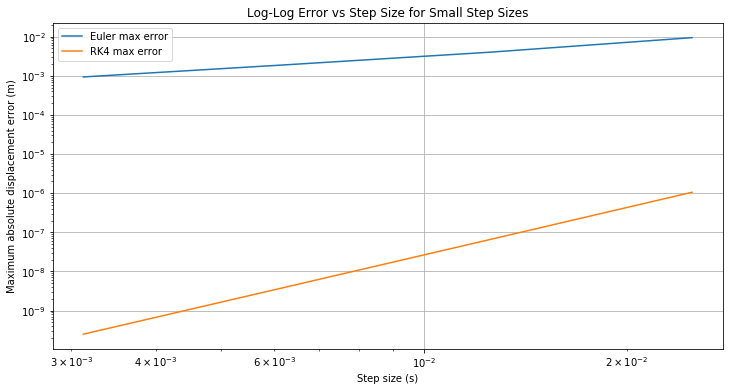

In [7]:
# Log-log error plot
h_small = [0.025, 0.0125, 0.00625, 0.003125]
euler_error_small = []
rk4_error_small = []

for h in h_small:
    t_values, y_values, v_values = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    y_exact, v_exact = analytical_solution(t_values)
    euler_error_small.append(np.max(np.abs(y_values - y_exact)))
    t_values4, y_values4, v_values4 = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    rk4_error_small.append(np.max(np.abs(y_values4 - y_exact)))

euler_fit = np.polyfit(np.log(h_small), np.log(euler_error_small), 1)
rk4_fit = np.polyfit(np.log(h_small), np.log(rk4_error_small), 1)

print("euler_slope =", euler_fit[0])
print("rk4_slope =", rk4_fit[0])

plt.figure(figsize=(12, 6))
plt.loglog(h_small, euler_error_small, label="Euler max error")
plt.loglog(h_small, rk4_error_small, label="RK4 max error")

plt.xlabel("Step size (s)")
plt.ylabel("Maximum absolute displacement error (m)")
plt.title("Log-Log Error vs Step Size for Small Step Sizes")
plt.legend()
plt.grid(True)

plt.show()

For the stability limits of each method, the step size was calculated to be 0.0625 for the Euler method and 0.362 for the RK4 method. We can see when plotting a step size of 0.1 for euler and 0.5 for RK4 that the methods are unstable, they converge from the analytical solution as t increases. We can also see that RK4 is stable at an h value of 0.25 and euler is stable at an h value of 0.05. 

If we look at the absolute displacement error vs time graphs for differing h values, we can see that as expected, as the step size decreases the absolute displacement error decreases. The error also decreases as time increases; however, this is due to the analytical solution decaying towards 0. We can see when looking at the scale on the y axis that RK4 is much more accurate that euler at the same step sizes and its error also decreases quicker as step size decreases showing a greater sensitivty in its error to the step size. 

If we look at the log-log error vs step size graph, small step sizes had to be used as euler only converges for step sizes less than 0.0625. We can see that the slope for euler is ~1 and the slope for RK4 is ~4 which is whats expected in theory. This shows that the error of the RK4 method stays very small until the boundary of the stability region is approached opposed to euler where the errors grow quicker before reaching the boundary of the stability region. This is why RK4 is more sensitive with regards to step size when looking at accuracy. 

With regards to the physical system, the system is oscilatory in nature and loses energy as time goes on. The stable solutions follow that trend of decay; however, the unstable ones do not. Effectively, within a methods stability region the method converges on an analytical solution with time but outside it the method diverges. 

In conclusion, RK4 performed better for this problem. It had smaller displacement errors at the same step size of euler and thus was better for modeling the oscilation and decay of the system. The measured slopes of the log-log error vs step size also match the expectations very well. Euler is computationally cheaper but less accurate while RK4 is more expensive yet more accurate. For a problem like this, RK4 is more useful as computational power is not limited but in a situation where modeling has to be done very rapidly with very small step sizes euler could be more useful as at small step sizes it is still accurate while preserving compute. In the end, the main lesson learned is that stability limits are very important but a model that is less accurate can still be more useful as its computationally cheaper and can still be accurate at small step sizes.

Sources:
Source 1: Combined MPG for Versa with Manual Transmission. 32 City MPG / 40 Highway MPG / 35 Combined MPG for Versa with Xtronic CVT. Retrieved April 30, 2026, from https://www.nissanusa.com/content/dam/Nissan/us/vehicle-brochures/2025/2025-nissan-versa-brochure-en.pdf
Source 2: Kim, H. (2025). Evaluation of a Series-Type Mount Structure for Electric Vehicle Suspension System. https://doi.org/10.3390/machines13100903
Source 3: Module 3: Toolbox of Individual Traffic Calming Measures Part 2. https://highways.dot.gov/safety/speed-management/traffic-calming-eprimer/module-3-part-2